# Gibbs chain verification - plot r histograms from two cases on same figure

In [32]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import toml
from fgbuster.observation_helpers import *
import micmac as micmac

from jax import config
config.update("jax_enable_x64", True)

In [33]:
sys.path.append(os.path.dirname(os.path.abspath('')))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('')))+'/tutorials/')

In [34]:
working_directory_path = os.path.abspath('') + '/'
directory_save_file = working_directory_path + 'save_directory/'
directory_toml_file = working_directory_path + 'main_params/'
directory_additional_params = working_directory_path + 'additional_params/'


## 1) Results from case without patches

In [35]:
# # ### d1s1 customized to have spv params in fgs model at nside 1, spv patches 0
# sub_step_sampling_nopatches = 50
# num_jobs_nopatches = 1
# file_ver_nopatches = 'corr_cutsky_d1s1customparam_LB_r0_compsepns0_v3e_{}_{}'
# path_additional_params_nopatches = directory_additional_params + 'add_corr_cutsky_LB_d1s1customparam_compsepns0_v3e.toml'

### d7s1 non-param customized to have spv scaling laws at nside 1
sub_step_sampling_nopatches = 50
num_jobs_nopatches = 1
file_ver_nopatches = 'corr_cutsky_d7s1customNonparam_LB_r0_compsepns0_v4b_{}_{}'
path_additional_params_nopatches = directory_additional_params + 'add_corr_cutsky_LB_d7s1customNonparam_compsepns0_v4b.toml'

In [36]:
with open(path_additional_params_nopatches) as f:
    dictionary_additional_parameters_nopatches = toml.load(f)
f.close()

name_toml_nopatches = dictionary_additional_parameters_nopatches['name_toml']
name_file_spv_nopatches = dictionary_additional_parameters_nopatches['name_file_spv']
print("Using toml file: ", name_toml_nopatches)

Using toml file:  corr_cutsky_d7s1customNonparam_LB_r0_compsepns0_v4b.toml


In [37]:
with open(path_additional_params_nopatches) as f:
    dictionary_additional_parameters_nopatches = toml.load(f)
f.close()

In [38]:
path_toml_file_nopatches = directory_toml_file + name_toml_nopatches
if name_file_spv_nopatches != '':
    path_file_spv_nopatches = directory_toml_file + name_file_spv_nopatches
else:
    path_file_spv_nopatches = ''

In [39]:
MICMAC_sampler_obj_nopatches = micmac.create_MICMAC_sampler_from_toml_file(path_toml_file_nopatches, path_file_spv_nopatches)

<_io.TextIOWrapper name='/Users/arizzieri/APC/PhD/cmb_work/comp_sep/Non_param/MICMAC/test_playground/Paper_runs_v4_customizedFG/main_params/params_spv_LB_nside0.yaml' mode='r' encoding='UTF-8'>
count_b: 26
n_betas:  26

>>> Tree of spv config as passed by the User:
root
  nside_spv
    default: [0]
    f1
      default: None
      b0
        default: None
      b1
        default: None
      b2
        default: None
      b3
        default: None
      b4
        default: None
      b5
        default: None
      b6
        default: None
      b7
        default: None
      b8
        default: None
      b9
        default: None
      b10
        default: None
      b11
        default: None
      b12
        default: None
    f2
      default: [0]
      b0
        default: None
      b1
        default: None
      b2
        default: None
      b3
        default: None
      b4
        default: None
      b5
        default: None
      b6
        default: None
      b7
        default

In [40]:
if (MICMAC_sampler_obj_nopatches.number_iterations_sampling > 100) and (sub_step_sampling_nopatches==1):
    sub_step_sampling_nopatches = 50
elif MICMAC_sampler_obj_nopatches.number_iterations_sampling > 1000:
    sub_step_sampling_nopatches = 100
elif MICMAC_sampler_obj_nopatches.number_iterations_sampling > 3000:
    sub_step_sampling_nopatches = 200

In [41]:
all_r_samples_nopatches = []

for job in range(num_jobs_nopatches):

    if MICMAC_sampler_obj_nopatches.sample_r_Metropolis:
        all_r_samples_path_nopatches = directory_save_file+file_ver_nopatches.format(job,num_jobs_nopatches)+'_all_r_samples.npy'
        all_r_samples_nopatches.append(np.load(all_r_samples_path_nopatches))

if MICMAC_sampler_obj_nopatches.sample_r_Metropolis:
    all_r_samples_nopatches = np.array(all_r_samples_nopatches)

### Studying $r$

In [42]:
all_r_samples_nopatches.shape

(1, 4001)

In [43]:
all_r_samples_nopatches[0,-500:].shape

(500,)

In [44]:
print(all_r_samples_nopatches[0,:].mean(),
all_r_samples_nopatches[0,-4000:].mean(), 
all_r_samples_nopatches[0,-3000:].mean(), 
all_r_samples_nopatches[0,-2000:].mean(), 
all_r_samples_nopatches[0,-1000:].mean(), 
all_r_samples_nopatches[0,-500:].mean())

0.012014337640492331 0.012017341212046591 0.013439303508497761 0.013678129011139016 0.013430668677445272 0.01321035909986383


In [45]:
print(all_r_samples_nopatches[0,:].std(),
# all_r_samples_nopatches[0,-6000:].std(),
# all_r_samples_nopatches[0,-5000:].std(),
all_r_samples_nopatches[0,-4000:].std(), 
all_r_samples_nopatches[0,-3000:].std(), 
all_r_samples_nopatches[0,-2000:].std(), 
all_r_samples_nopatches[0,-1000:].std(), 
all_r_samples_nopatches[0,-500:].std())

0.0030838868374006437 0.0030784153107777782 0.0006333386335155982 0.00047015799166230356 0.0003263828988181275 0.00018454794620993695


In [46]:
# burn in chosen on previous two cell values
remaining_steps_nopatches = 2000    # d1s1 customized: 2000    # d7s1customized: 2000
burn_in_nopatches = all_r_samples_nopatches.shape[1] - remaining_steps_nopatches
print("burn in: ", burn_in_nopatches)
print("n remaining steps: ", remaining_steps_nopatches)

burn in:  2001
n remaining steps:  2000


0.012014337640492331 0.0030838868374006437


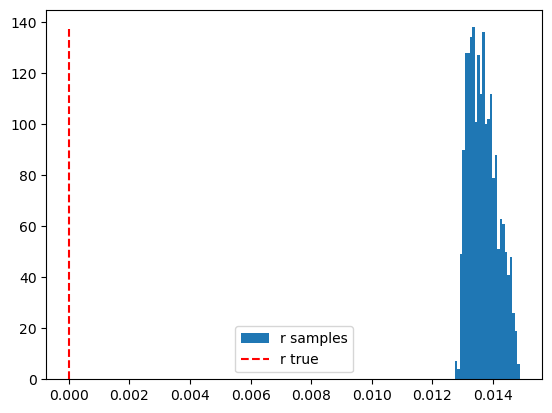

In [47]:
if MICMAC_sampler_obj_nopatches.sample_r_Metropolis:
    for job in range(num_jobs_nopatches):
        max_number_iterations_r_nopatches = MICMAC_sampler_obj_nopatches.number_iterations_sampling+1
        if len(all_r_samples_nopatches.shape) >= 3:
            max_number_iterations_r_nopatches = all_r_samples_nopatches.shape[1]*all_r_samples_nopatches.shape[2]
        else:
            max_number_iterations_r_nopatches = all_r_samples_nopatches.shape[1]
        
        all_r_samples_job_nopatches = all_r_samples_nopatches[job].squeeze().reshape(max_number_iterations_r_nopatches,1)
        
        if MICMAC_sampler_obj_nopatches.non_centered_moves:
            # max_number_iterations_r_2 = all_r_samples_job[::2].shape[0]
            all_r_sample_to_plot_nopatches = all_r_samples_job_nopatches[::2]
        else:
            # max_number_iterations_r_2 = all_r_samples_job.shape[0]
            all_r_sample_to_plot_nopatches = all_r_samples_nopatches[job]
        plt.figure()
        hist_values_nopatches, bins_value_nopatches, _ = plt.hist(all_r_sample_to_plot_nopatches[burn_in_nopatches:], bins='rice', label='r samples')
        plt.plot([MICMAC_sampler_obj_nopatches.r_true,MICMAC_sampler_obj_nopatches.r_true], [0,hist_values_nopatches.max()], 'r--', label='r true')
        plt.legend()
        print(np.mean(all_r_samples_nopatches[job]), np.std(all_r_samples_nopatches[job]))
    plt.show()

## 2) Results from case with patches (ns1)

In [48]:
# ### d1s1 customized to have spv params in fgs model at nside 1, spv patches 1
# sub_step_sampling_ns1 = 50
# num_jobs_ns1 = 1
# file_ver_ns1 = 'corr_cutsky_d1s1customparam_LB_r0_v3e_{}_{}'
# path_additional_params_ns1 = directory_additional_params + 'add_corr_cutsky_LB_d1s1customparam_v3e.toml'

## d7s1 non-param customized to have spv scaling laws at nside 1, with correction for negative r
sub_step_sampling_ns1 = 50
num_jobs_ns1 = 1
file_ver_ns1 = 'corr_cutsky_d7s1customNonparam_LB_r0_v4b_{}_{}'
path_additional_params_ns1 = directory_additional_params + 'add_corr_cutsky_LB_d7s1customNonparam_v4b.toml'

In [49]:
with open(path_additional_params_ns1) as f:
    dictionary_additional_parameters_ns1 = toml.load(f)
f.close()

name_toml_ns1 = dictionary_additional_parameters_ns1['name_toml']
name_file_spv_ns1 = dictionary_additional_parameters_ns1['name_file_spv']
print("Using toml file: ", name_toml_ns1)

Using toml file:  corr_cutsky_d7s1customNonparam_LB_r0_v4b.toml


In [50]:
with open(path_additional_params_ns1) as f:
    dictionary_additional_parameters_ns1 = toml.load(f)
f.close()

In [51]:
path_toml_file_ns1 = directory_toml_file + name_toml_ns1
if name_file_spv_ns1 != '':
    path_file_spv_ns1 = directory_toml_file + name_file_spv_ns1
else:
    path_file_spv_ns1 = ''

In [52]:
MICMAC_sampler_obj_ns1 = micmac.create_MICMAC_sampler_from_toml_file(path_toml_file_ns1, path_file_spv_ns1)

<_io.TextIOWrapper name='/Users/arizzieri/APC/PhD/cmb_work/comp_sep/Non_param/MICMAC/test_playground/Paper_runs_v4_customizedFG/main_params/params_spv_LB_nside1.yaml' mode='r' encoding='UTF-8'>
count_b: 26
n_betas:  26

>>> Tree of spv config as passed by the User:
root
  nside_spv
    default: [1]
    f1
      default: None
      b0
        default: None
      b1
        default: None
      b2
        default: None
      b3
        default: None
      b4
        default: None
      b5
        default: None
      b6
        default: None
      b7
        default: None
      b8
        default: None
      b9
        default: None
      b10
        default: None
      b11
        default: None
      b12
        default: None
    f2
      default: [1]
      b0
        default: None
      b1
        default: None
      b2
        default: None
      b3
        default: None
      b4
        default: None
      b5
        default: None
      b6
        default: None
      b7
        default

In [53]:
if (MICMAC_sampler_obj_ns1.number_iterations_sampling > 100) and (sub_step_sampling_ns1==1):
    sub_step_sampling_ns1 = 50
elif MICMAC_sampler_obj_ns1.number_iterations_sampling > 1000:
    sub_step_sampling_ns1 = 100
elif MICMAC_sampler_obj_ns1.number_iterations_sampling > 3000:
    sub_step_sampling_ns1 = 200

In [54]:
all_r_samples_ns1 = []

for job in range(num_jobs_ns1):

    if MICMAC_sampler_obj_ns1.sample_r_Metropolis:
        all_r_samples_path_ns1 = directory_save_file+file_ver_ns1.format(job,num_jobs_ns1)+'_all_r_samples.npy'
        all_r_samples_ns1.append(np.load(all_r_samples_path_ns1))

if MICMAC_sampler_obj_ns1.sample_r_Metropolis:
    all_r_samples_ns1 = np.array(all_r_samples_ns1)

### Studying $r$

In [55]:
all_r_samples_ns1.shape

(1, 4001)

In [56]:
print(all_r_samples_ns1[0,:].mean(),
all_r_samples_ns1[0,-4000:].mean(), 
all_r_samples_ns1[0,-3000:].mean(), 
all_r_samples_ns1[0,-2000:].mean(), 
all_r_samples_ns1[0,-1000:].mean(), 
all_r_samples_ns1[0,-500:].mean())

0.0002101370191938442 0.00021018952938243234 0.00018166008927397135 0.00018832971668795014 7.494820528121878e-05 0.0001051638512549121


In [57]:
print(all_r_samples_ns1[0,:].std(),
all_r_samples_ns1[0,-4000:].std(), 
all_r_samples_ns1[0,-3000:].std(), 
all_r_samples_ns1[0,-2000:].std(), 
all_r_samples_ns1[0,-1000:].std(), 
all_r_samples_ns1[0,-500:].std())

0.00021333764083186877 0.00021333845222091171 0.00020404489753491622 0.00021620843425213763 0.00011771782109874436 0.0001377217339787395


In [58]:
# burn in chosen on previous two cell values
remaining_steps_ns1 = 3500   # d1s1 customized: 2000    # d7s1customized: 3500
burn_in_ns1 = all_r_samples_ns1.shape[1] - remaining_steps_ns1
print("burn in: ", burn_in_ns1)
print("n remaining steps: ", remaining_steps_ns1)

burn in:  501
n remaining steps:  3500


0.0002101370191938442 0.00021333764083186877


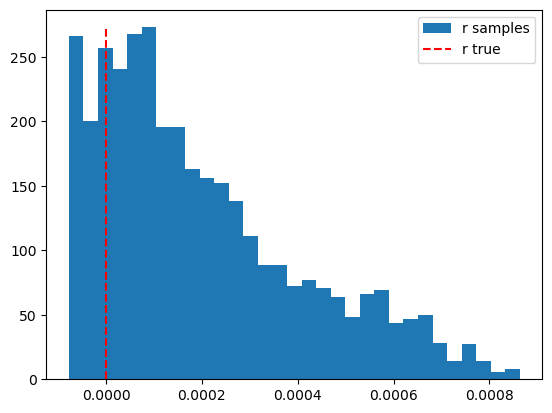

In [59]:
if MICMAC_sampler_obj_ns1.sample_r_Metropolis:
    for job in range(num_jobs_ns1):
        max_number_iterations_r_ns1 = MICMAC_sampler_obj_ns1.number_iterations_sampling+1
        if len(all_r_samples_ns1.shape) >= 3:
            max_number_iterations_r_ns1 = all_r_samples_ns1.shape[1]*all_r_samples_ns1.shape[2]
        else:
            max_number_iterations_r_ns1 = all_r_samples_ns1.shape[1]
        
        all_r_samples_job_ns1 = all_r_samples_ns1[job].squeeze().reshape(max_number_iterations_r_ns1,1)
        
        if MICMAC_sampler_obj_ns1.non_centered_moves:
            # max_number_iterations_r_2 = all_r_samples_job[::2].shape[0]
            all_r_sample_to_plot_ns1 = all_r_samples_job_ns1[::2]
        else:
            # max_number_iterations_r_2 = all_r_samples_job.shape[0]
            all_r_sample_to_plot_ns1 = all_r_samples_ns1[job]
        plt.figure()
        hist_values_ns1, bins_value_ns1, _ = plt.hist(all_r_sample_to_plot_ns1[burn_in_ns1:], bins='rice', label='r samples')
        plt.plot([MICMAC_sampler_obj_ns1.r_true,MICMAC_sampler_obj_ns1.r_true], [0,hist_values_ns1.max()], 'r--', label='r true')
        plt.legend()
        print(np.mean(all_r_samples_ns1[job]), np.std(all_r_samples_ns1[job]))
    plt.show()

0.0002101370191938442 0.00021333764083186877


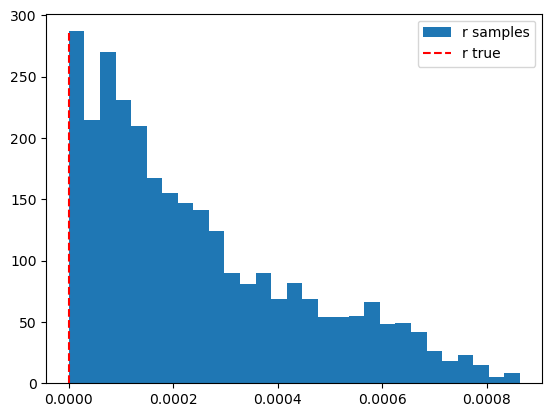

In [60]:
# get rid of values < 0
if MICMAC_sampler_obj_ns1.sample_r_Metropolis:
    for job in range(num_jobs_ns1):
        max_number_iterations_r_ns1 = MICMAC_sampler_obj_ns1.number_iterations_sampling+1
        if len(all_r_samples_ns1.shape) >= 3:
            max_number_iterations_r_ns1 = all_r_samples_ns1.shape[1]*all_r_samples_ns1.shape[2]
        else:
            max_number_iterations_r_ns1 = all_r_samples_ns1.shape[1]
        
        all_r_samples_job_ns1 = all_r_samples_ns1[job].squeeze().reshape(max_number_iterations_r_ns1,1)
        
        if MICMAC_sampler_obj_ns1.non_centered_moves:
            # max_number_iterations_r_2 = all_r_samples_job[::2].shape[0]
            all_r_sample_to_plot_ns1 = all_r_samples_job_ns1[::2]
        else:
            # max_number_iterations_r_2 = all_r_samples_job.shape[0]
            all_r_sample_to_plot_ns1 = all_r_samples_ns1[job]
        all_r_sample_to_plot_ns1 = all_r_sample_to_plot_ns1[all_r_sample_to_plot_ns1 >= 0]
        plt.figure()
        hist_values_ns1, bins_value_ns1, _ = plt.hist(all_r_sample_to_plot_ns1[burn_in_ns1:], bins='rice', label='r samples')
        plt.plot([MICMAC_sampler_obj_ns1.r_true,MICMAC_sampler_obj_ns1.r_true], [0,hist_values_ns1.max()], 'r--', label='r true')
        plt.legend()
        print(np.mean(all_r_samples_ns1[job]), np.std(all_r_samples_ns1[job]))
    plt.show()

## Plot with both results

mean, std run w/o patches:  0.013678129011139016 0.00047015799166230356
mean, std run w patches:  0.00024733194264192393 0.00020150672874882233


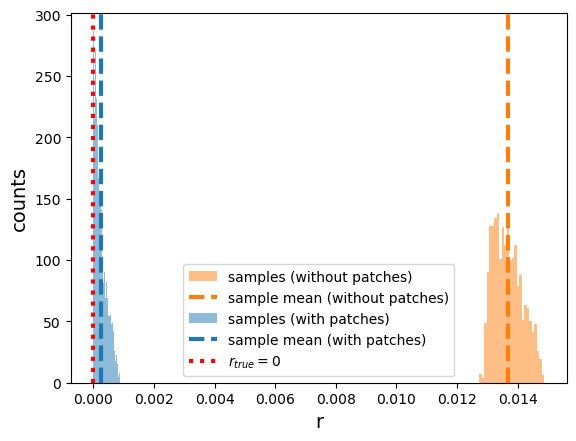

In [61]:
# without any normalization in the histograms
assert MICMAC_sampler_obj_ns1.sample_r_Metropolis == MICMAC_sampler_obj_nopatches.sample_r_Metropolis
assert num_jobs_ns1 == num_jobs_nopatches
assert len(all_r_samples_ns1.shape) == len(all_r_samples_nopatches.shape)
assert MICMAC_sampler_obj_ns1.non_centered_moves == MICMAC_sampler_obj_nopatches.non_centered_moves
assert MICMAC_sampler_obj_ns1.number_iterations_sampling == MICMAC_sampler_obj_nopatches.number_iterations_sampling

if MICMAC_sampler_obj_ns1.sample_r_Metropolis:
    for job in range(num_jobs_ns1):
        max_number_iterations_r_ns1 = MICMAC_sampler_obj_ns1.number_iterations_sampling+1
        max_number_iterations_r_nopatches = MICMAC_sampler_obj_nopatches.number_iterations_sampling+1
        if len(all_r_samples_ns1.shape) >= 3:
            max_number_iterations_r_ns1 = all_r_samples_ns1.shape[1]*all_r_samples_ns1.shape[2]
            max_number_iterations_r_nopatches = all_r_samples_nopatches.shape[1]*all_r_samples_nopatches.shape[2]
        else:
            max_number_iterations_r_ns1 = all_r_samples_ns1.shape[1]
            max_number_iterations_r_nopatches = all_r_samples_nopatches.shape[1]
        
        all_r_samples_job_ns1 = all_r_samples_ns1[job].squeeze().reshape(max_number_iterations_r_ns1,1)
        all_r_samples_job_nopatches = all_r_samples_nopatches[job].squeeze().reshape(max_number_iterations_r_nopatches,1)
        
        if MICMAC_sampler_obj_ns1.non_centered_moves:
            # max_number_iterations_r_2 = all_r_samples_job[::2].shape[0]
            all_r_sample_to_plot_ns1 = all_r_samples_job_ns1[::2]
            all_r_sample_to_plot_nopatches = all_r_samples_job_nopatches[::2]
        else:
            # max_number_iterations_r_2 = all_r_samples_job.shape[0]
            all_r_sample_to_plot_ns1 = all_r_samples_ns1[job]
            all_r_sample_to_plot_nopatches = all_r_samples_nopatches[job]
        all_r_sample_to_plot_ns1 = all_r_sample_to_plot_ns1[all_r_sample_to_plot_ns1 >= 0]
        plt.figure()
        hist_values_nopatches, bins_value_nopatches, _ = plt.hist(all_r_sample_to_plot_nopatches[burn_in_nopatches:], color='tab:orange', bins='rice', alpha=0.5, label='samples (without patches)')   #, density=True
        plt.axvline(np.mean(all_r_sample_to_plot_nopatches[burn_in_nopatches:]), label='sample mean (without patches)', color='tab:orange', linestyle='--', linewidth=3)
        hist_values_ns1, bins_value_ns1, _ = plt.hist(all_r_sample_to_plot_ns1[burn_in_ns1:], bins='rice', alpha=0.5, label='samples (with patches)')   #, density=True
        plt.axvline(np.mean(all_r_sample_to_plot_ns1[burn_in_ns1:]), label='sample mean (with patches)', color='tab:blue', linestyle='--', linewidth=3)
        #plt.plot([MICMAC_sampler_obj_ns1.r_true,MICMAC_sampler_obj_ns1.r_true], [0,hist_values_ns1.max()], 'r--', label='r true', linewidth=3)
        plt.axvline(MICMAC_sampler_obj_ns1.r_true, label=r'$r_{true}=0$', color='red', linestyle=':', linewidth=3)
        plt.xlabel('r', fontsize=14)
        plt.ylabel('counts', fontsize=14)
        plt.legend()
        print('mean, std run w/o patches: ', np.mean(all_r_sample_to_plot_nopatches[burn_in_nopatches:]), np.std(all_r_sample_to_plot_nopatches[burn_in_nopatches:]))
        print('mean, std run w patches: ', np.mean(all_r_sample_to_plot_ns1[burn_in_ns1:]), np.std(all_r_sample_to_plot_ns1[burn_in_ns1:]))
    plt.show()

mean, std run w/o patches:  0.013678129011139016 0.00047015799166230356
mean, std run w patches:  0.00024733194264192393 0.00020150672874882233


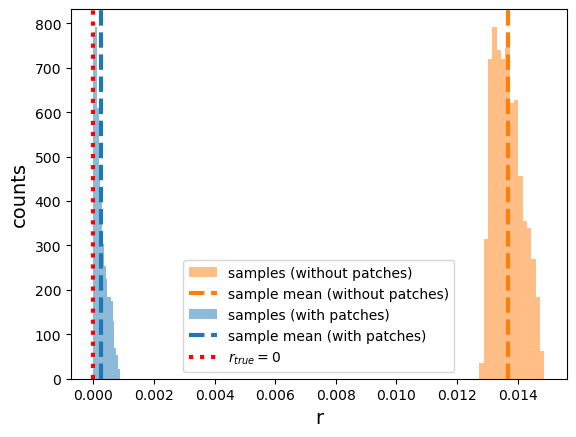

In [62]:
# with normalization in the histograms (peakes at same heigth)
assert MICMAC_sampler_obj_ns1.sample_r_Metropolis == MICMAC_sampler_obj_nopatches.sample_r_Metropolis
assert num_jobs_ns1 == num_jobs_nopatches
assert len(all_r_samples_ns1.shape) == len(all_r_samples_nopatches.shape)
assert MICMAC_sampler_obj_ns1.non_centered_moves == MICMAC_sampler_obj_nopatches.non_centered_moves
assert MICMAC_sampler_obj_ns1.number_iterations_sampling == MICMAC_sampler_obj_nopatches.number_iterations_sampling

if MICMAC_sampler_obj_ns1.sample_r_Metropolis:
    for job in range(num_jobs_ns1):
        max_number_iterations_r_ns1 = MICMAC_sampler_obj_ns1.number_iterations_sampling+1
        max_number_iterations_r_nopatches = MICMAC_sampler_obj_nopatches.number_iterations_sampling+1
        if len(all_r_samples_ns1.shape) >= 3:
            max_number_iterations_r_ns1 = all_r_samples_ns1.shape[1]*all_r_samples_ns1.shape[2]
            max_number_iterations_r_nopatches = all_r_samples_nopatches.shape[1]*all_r_samples_nopatches.shape[2]
        else:
            max_number_iterations_r_ns1 = all_r_samples_ns1.shape[1]
            max_number_iterations_r_nopatches = all_r_samples_nopatches.shape[1]
        
        all_r_samples_job_ns1 = all_r_samples_ns1[job].squeeze().reshape(max_number_iterations_r_ns1,1)
        all_r_samples_job_nopatches = all_r_samples_nopatches[job].squeeze().reshape(max_number_iterations_r_nopatches,1)
        
        if MICMAC_sampler_obj_ns1.non_centered_moves:
            # max_number_iterations_r_2 = all_r_samples_job[::2].shape[0]
            all_r_sample_to_plot_ns1 = all_r_samples_job_ns1[::2]
            all_r_sample_to_plot_nopatches = all_r_samples_job_nopatches[::2]
        else:
            # max_number_iterations_r_2 = all_r_samples_job.shape[0]
            all_r_sample_to_plot_ns1 = all_r_samples_ns1[job]
            all_r_sample_to_plot_nopatches = all_r_samples_nopatches[job]
        all_r_sample_to_plot_ns1 = all_r_sample_to_plot_ns1[all_r_sample_to_plot_ns1 >= 0]
        plt.figure()
        hist_values_nopatches, bins_value_nopatches, _ = plt.hist(all_r_sample_to_plot_nopatches[burn_in_nopatches:], color='tab:orange', bins=15, alpha=0.5, label='samples (without patches)', density=True)
        plt.axvline(np.mean(all_r_sample_to_plot_nopatches[burn_in_nopatches:]), label='sample mean (without patches)', color='tab:orange', linestyle='--', linewidth=3)
        hist_values_ns1, bins_value_ns1 = np.histogram(all_r_sample_to_plot_ns1[burn_in_ns1:], bins=15, density=False)   # , alpha=0.5, label='samples (with patches)',
        hist_values_ns1, bins_value_ns1, _ = plt.hist(all_r_sample_to_plot_ns1[burn_in_ns1:], bins=bins_value_ns1, alpha=0.5, label='samples (with patches)', weights=hist_values_nopatches.max()*np.ones_like(all_r_sample_to_plot_ns1[burn_in_ns1:])/hist_values_ns1.max())
        plt.axvline(np.mean(all_r_sample_to_plot_ns1[burn_in_ns1:]), label='sample mean (with patches)', color='tab:blue', linestyle='--', linewidth=3)
        #plt.plot([MICMAC_sampler_obj_ns1.r_true,MICMAC_sampler_obj_ns1.r_true], [0,hist_values_ns1.max()], 'r--', label='r true', linewidth=3)
        plt.axvline(MICMAC_sampler_obj_ns1.r_true, label=r'$r_{true}=0$', color='red', linestyle=':', linewidth=3)
        plt.xlabel('r', fontsize=14)
        plt.ylabel('counts', fontsize=14)
        plt.legend()
        print('mean, std run w/o patches: ', np.mean(all_r_sample_to_plot_nopatches[burn_in_nopatches:]), np.std(all_r_sample_to_plot_nopatches[burn_in_nopatches:]))
        print('mean, std run w patches: ', np.mean(all_r_sample_to_plot_ns1[burn_in_ns1:]), np.std(all_r_sample_to_plot_ns1[burn_in_ns1:]))
    plt.show()

TODO: to keep the mean lines or not?? Or fit gaussians? Change the labels with/without patches?